# Feature Selection

## Objective

After creating advanced behavioural and historical features, the dataset contains a large number of predictors.

Not every feature contributes positively to model performance.

This notebook identifies the most informative variables using statistical methods and machine learning based feature selection techniques.

The final selected features will be used in Notebook 6 for model development.

In [57]:
# ============================================================
# Imports
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.feature_selection import (

    mutual_info_classif,

    VarianceThreshold,

    RFE

)

from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier

SEED = 42

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [58]:
from pathlib import Path

DATA = Path("../data")

df = pd.read_csv(
    DATA / "fraud_detection_enhanced.csv"
)

print(df.shape)

(5000000, 52)


In [59]:
# ============================================================
# Dataset Overview
# ============================================================

print("=" * 60)
print("Dataset Shape")
print("=" * 60)

print(df.shape)

print()

print("=" * 60)
print("Target Distribution")
print("=" * 60)

print(df["is_fraud"].value_counts())

print()

print(df["is_fraud"].value_counts(normalize=True))

Dataset Shape
(5000000, 52)

Target Distribution
is_fraud
False    4820447
True      179553
Name: count, dtype: int64

is_fraud
False    0.964089
True     0.035911
Name: proportion, dtype: float64


In [60]:
# ============================================================
# Data Types
# ============================================================

display(df.dtypes.value_counts())

float64    28
str        13
int64      10
bool        1
Name: count, dtype: int64

In [61]:
# ============================================================
# Missing Values
# ============================================================

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

display(
    missing[missing > 0]
)

fraud_type                     4820447
previous_timestamp              896513
amount_difference               896513
time_since_last_transaction     896513
dtype: int64

# Remove Leakage Features

Before feature selection, remove variables that:

- uniquely identify transactions
- contain future information
- cannot be known at prediction time

These variables would artificially inflate model performance.

In [62]:
# ============================================================
# Remove Leakage Features
# ============================================================

drop_columns = [

    "transaction_id",
    "timestamp",
    "fraud_type"

]

# Drop only if they exist
drop_columns = [c for c in drop_columns if c in df.columns]

df.drop(columns=drop_columns, inplace=True)

print("Dropped Columns:")
print(drop_columns)

print()

print("Dataset Shape:", df.shape)

Dropped Columns:
['transaction_id', 'timestamp', 'fraud_type']

Dataset Shape: (5000000, 49)


In [63]:
# ============================================================
# Feature Matrix
# ============================================================

X = df.drop("is_fraud", axis=1)

y = df["is_fraud"]

print("Feature Matrix :", X.shape)
print("Target :", y.shape)

Feature Matrix : (5000000, 48)
Target : (5000000,)


In [64]:
# ============================================================
# Numerical and Categorical Features
# ============================================================

numerical_features = (
    X.select_dtypes(include=np.number)
     .columns
     .tolist()
)

categorical_features = (
    X.select_dtypes(exclude=np.number)
     .columns
     .tolist()
)

print("Numerical Features :", len(numerical_features))
print("Categorical Features :", len(categorical_features))

print("\nNumerical Columns")
print(numerical_features)

print("\nCategorical Columns")
print(categorical_features)

Numerical Features : 38
Categorical Features : 10

Numerical Columns
['amount', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'historical_txn_count', 'historical_avg_amount', 'historical_max_amount', 'historical_min_amount', 'historical_std_amount', 'amount_ratio', 'amount_difference', 'time_gap_minutes', 'previous_amount', 'amount_change', 'amount_pct_change', 'historical_total_amount', 'historical_median_amount', 'amount_median_ratio', 'time_gap_hours', 'rapid_transaction', 'days_since_first_txn', 'avg_txn_per_day', 'sender_account_age_days', 'sender_unique_receivers', 'receiver_diversity_ratio', 'receiver_transaction_count', 'receiver_unique_senders', 'device_usage_count', 'accounts_per_device', 'location_transaction_count', 'location_unique_users', 'amount_velocity', 'amount_geo', 'amount_spending', 'velocity_geo', 'velocity_spending', 'geo_spending']

Categorical Columns
['sender_account', 'receiver_account', 'transaction_type', 

In [65]:
from sklearn.feature_selection import VarianceThreshold

# ============================================================
# Remove Constant Features
# ============================================================

selector = VarianceThreshold(threshold=0)

selector.fit(X[numerical_features])

selected_num = [
    col
    for col, keep in zip(
        numerical_features,
        selector.get_support()
    )
    if keep
]

removed_features = list(
    set(numerical_features) -
    set(selected_num)
)

print("=" * 60)
print("Constant Features Removed")
print("=" * 60)

print(removed_features)

print()

print("Total Removed:", len(removed_features))

Constant Features Removed
[]

Total Removed: 0


In [66]:
df.drop(columns=["previous_timestamp"], inplace=True)

In [67]:
df.drop(columns=["time_since_last_transaction"], inplace=True)

In [68]:
identifier_columns = [
    "sender_account",
    "receiver_account",
    "ip_address",
    "device_hash"
]

df.drop(columns=identifier_columns, inplace=True)

In [69]:
from sklearn.model_selection import train_test_split

# ============================================================
# Create Representative Sample
# ============================================================

sample_df, _ = train_test_split(
    df,
    train_size=500_000,
    stratify=df["is_fraud"],
    random_state=42
)

sample_df = sample_df.reset_index(drop=True)

print("Sample Shape:", sample_df.shape)

print("\nFraud Distribution:")

print(sample_df["is_fraud"].value_counts())

print()

print(sample_df["is_fraud"].value_counts(normalize=True))

Sample Shape: (500000, 43)

Fraud Distribution:
is_fraud
False    482045
True      17955
Name: count, dtype: int64

is_fraud
False    0.96409
True     0.03591
Name: proportion, dtype: float64


In [70]:
print(sample_df.columns.tolist())

['amount', 'transaction_type', 'merchant_category', 'location', 'device_used', 'is_fraud', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'payment_channel', 'historical_txn_count', 'historical_avg_amount', 'historical_max_amount', 'historical_min_amount', 'historical_std_amount', 'amount_ratio', 'amount_difference', 'time_gap_minutes', 'previous_amount', 'amount_change', 'amount_pct_change', 'historical_total_amount', 'historical_median_amount', 'amount_median_ratio', 'time_gap_hours', 'rapid_transaction', 'days_since_first_txn', 'avg_txn_per_day', 'sender_account_age_days', 'sender_unique_receivers', 'receiver_diversity_ratio', 'receiver_transaction_count', 'receiver_unique_senders', 'device_usage_count', 'accounts_per_device', 'location_transaction_count', 'location_unique_users', 'amount_velocity', 'amount_geo', 'amount_spending', 'velocity_geo', 'velocity_spending', 'geo_spending']


In [71]:
print(sample_df.head())

    amount transaction_type merchant_category location device_used  is_fraud  \
0     4.78         transfer           grocery    Dubai         web     False   
1    29.61         transfer        restaurant   London      mobile     False   
2    15.36         transfer            retail    Tokyo         web     False   
3   530.65          payment     entertainment   London         web     False   
4  1392.51          deposit             other   Berlin         web     False   

   spending_deviation_score  velocity_score  geo_anomaly_score  \
0                     -0.57               6               0.19   
1                      0.47              13               0.82   
2                      1.14              12               0.09   
3                     -0.27              13               0.92   
4                      1.07              15               0.74   

  payment_channel  historical_txn_count  historical_avg_amount  \
0            card                     2             602.

In [72]:
print(df.columns.tolist())

['amount', 'transaction_type', 'merchant_category', 'location', 'device_used', 'is_fraud', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'payment_channel', 'historical_txn_count', 'historical_avg_amount', 'historical_max_amount', 'historical_min_amount', 'historical_std_amount', 'amount_ratio', 'amount_difference', 'time_gap_minutes', 'previous_amount', 'amount_change', 'amount_pct_change', 'historical_total_amount', 'historical_median_amount', 'amount_median_ratio', 'time_gap_hours', 'rapid_transaction', 'days_since_first_txn', 'avg_txn_per_day', 'sender_account_age_days', 'sender_unique_receivers', 'receiver_diversity_ratio', 'receiver_transaction_count', 'receiver_unique_senders', 'device_usage_count', 'accounts_per_device', 'location_transaction_count', 'location_unique_users', 'amount_velocity', 'amount_geo', 'amount_spending', 'velocity_geo', 'velocity_spending', 'geo_spending']


In [73]:
df.drop(columns=["days_since_first_txn"], inplace=True)

In [74]:
df.drop(columns=["time_gap_hours"], inplace=True)

In [75]:
X_sample = sample_df.drop(columns=["is_fraud"])
y_sample = sample_df["is_fraud"]

In [76]:
# ============================================================
# Correlation Analysis
# ============================================================

corr_matrix = (
    X.select_dtypes(include=np.number)
     .corr()
)

In [77]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = []

for column in upper.columns:

    for row in upper.index:

        corr = upper.loc[row, column]

        if pd.notna(corr) and abs(corr) > 0.90:

            high_corr.append([

                row,

                column,

                round(corr,3)

            ])

corr_df = pd.DataFrame(

    high_corr,

    columns=[

        "Feature 1",

        "Feature 2",

        "Correlation"

    ]

)

display(corr_df)

,Feature 1,Feature 2,Correlation
0,historical_avg_amount,historical_median_amount,0.929
1,amount_ratio,amount_median_ratio,0.969
2,time_gap_minutes,time_gap_hours,1.000
3,days_since_first_txn,sender_account_age_days,1.000
4,device_usage_count,location_transaction_count,1.000


In [78]:
df.drop(columns=["amount_median_ratio"], inplace=True)

In [79]:
print(df["device_usage_count"].head(20))

print()

print(df["location_transaction_count"].head(20))

0     0
1     0
2     0
3     1
4     2
5     1
6     0
7     2
8     1
9     3
10    4
11    5
12    3
13    1
14    6
15    4
16    2
17    3
18    7
19    4
Name: device_usage_count, dtype: int64

0     0
1     0
2     0
3     0
4     1
5     0
6     0
7     1
8     2
9     1
10    3
11    1
12    1
13    2
14    2
15    3
16    4
17    0
18    2
19    3
Name: location_transaction_count, dtype: int64


In [80]:
from sklearn.model_selection import train_test_split

sample_df, _ = train_test_split(
    df,
    train_size=500_000,
    stratify=df["is_fraud"],
    random_state=42
)

sample_df.reset_index(drop=True, inplace=True)

print(sample_df.shape)

(500000, 40)


In [81]:
X_sample = sample_df.drop(columns=["is_fraud"])
y_sample = sample_df["is_fraud"]

In [82]:
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = (
    X_sample
    .select_dtypes(include=["object", "string"])
    .columns
)

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_encoded = X_sample.copy()

X_encoded[categorical_cols] = encoder.fit_transform(
    X_encoded[categorical_cols]
)

In [83]:
# ============================================================
# Missing Values in Sample
# ============================================================

missing = (
    X_encoded
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

display(missing)

amount_difference    89718
dtype: int64

In [84]:
# ============================================================
# Fill Remaining Missing Values
# ============================================================

X_encoded = X_encoded.fillna(0)

In [85]:
print(X_encoded.isnull().sum().sum())

0


In [86]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_encoded,
    y_sample,
    random_state=42,
    discrete_features="auto"
)

mi_df = (
    pd.DataFrame({
        "Feature": X_encoded.columns,
        "Mutual Information": mi_scores
    })
    .sort_values("Mutual Information", ascending=False)
    .reset_index(drop=True)
)

display(mi_df.head(20))

,Feature,Mutual Information
0,payment_channel,0.024615
1,transaction_type,0.024605
2,device_used,0.024480
3,accounts_per_device,0.019047
4,merchant_category,0.013543
5,location,0.013510
6,receiver_unique_senders,0.012529
7,sender_unique_receivers,0.012270
8,historical_txn_count,0.010483
9,location_unique_users,0.010433


# Random Forest Feature Importance

Random Forest estimates the predictive importance of each feature by measuring how much each variable contributes to reducing impurity across all decision trees.

Unlike correlation, Random Forest can capture nonlinear relationships and feature interactions.

In [87]:
# ============================================================
# Random Forest Feature Importance
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf.fit(X_encoded, y_sample)

rf_importance = pd.DataFrame({

    "Feature": X_encoded.columns,

    "RF Importance": rf.feature_importances_

})

rf_importance = rf_importance.sort_values(
    "RF Importance",
    ascending=False
).reset_index(drop=True)

display(rf_importance.head(20))

,Feature,RF Importance
0,velocity_geo,0.040103
1,velocity_spending,0.039110
2,geo_spending,0.038875
3,location_transaction_count,0.038504
4,device_usage_count,0.038328
5,amount_velocity,0.038218
6,amount_geo,0.037922
7,amount_spending,0.037612
8,spending_deviation_score,0.036668
9,geo_anomaly_score,0.036012


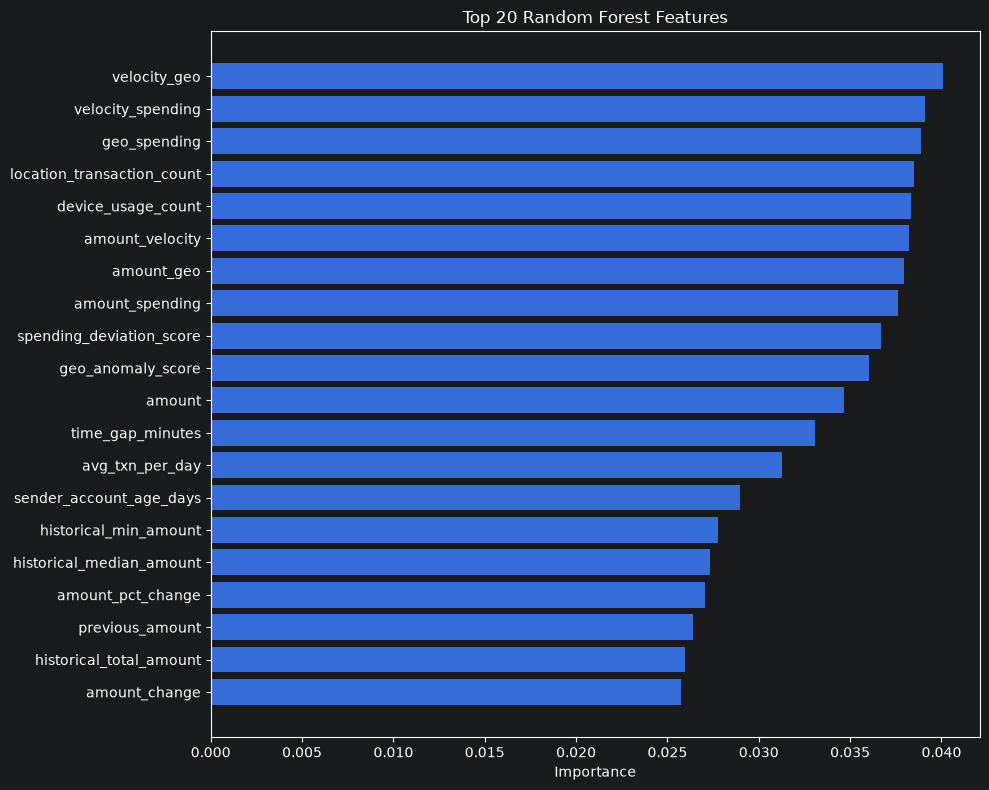

In [88]:
# ============================================================
# Random Forest Importance Plot
# ============================================================

top_rf = rf_importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_rf["Feature"][::-1],
    top_rf["RF Importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top 20 Random Forest Features")

plt.tight_layout()

plt.show()

In [89]:
# ============================================================
# LightGBM Feature Importance
# ============================================================

from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(

    random_state=42,

    n_estimators=300,

    class_weight="balanced",

    verbose=-1

)

lgbm.fit(
    X_encoded,
    y_sample
)

lgbm_importance = pd.DataFrame({

    "Feature": X_encoded.columns,

    "LGBM Importance": lgbm.feature_importances_

})

lgbm_importance = lgbm_importance.sort_values(

    "LGBM Importance",

    ascending=False

).reset_index(drop=True)

display(
    lgbm_importance.head(20)
)

,Feature,LGBM Importance
0,velocity_geo,465
1,time_gap_minutes,392
2,avg_txn_per_day,370
3,velocity_spending,363
4,geo_anomaly_score,363
5,geo_spending,351
6,amount_geo,348
7,spending_deviation_score,344
8,amount_velocity,324
9,sender_account_age_days,301


In [90]:
# ============================================================
# Combined Feature Ranking
# ============================================================

ranking = (
    mi_df
    .merge(
        rf_importance,
        on="Feature"
    )
    .merge(
        lgbm_importance,
        on="Feature"
    )
)

ranking["MI Rank"] = ranking["Mutual Information"].rank(
    ascending=False
)

ranking["RF Rank"] = ranking["RF Importance"].rank(
    ascending=False
)

ranking["LGBM Rank"] = ranking["LGBM Importance"].rank(
    ascending=False
)

ranking["Average Rank"] = (

    ranking["MI Rank"]

    +

    ranking["RF Rank"]

    +

    ranking["LGBM Rank"]

) / 3

ranking = ranking.sort_values(
    "Average Rank"
)

display(ranking.head(30))

,Feature,Mutual Information,RF Importance,LGBM Importance,MI Rank,RF Rank,LGBM Rank,Average Rank
15,velocity_geo,0.000471,0.040103,465,16.0,1.0,1.0,6.000000
13,geo_anomaly_score,0.001087,0.036012,363,14.0,10.0,4.5,9.500000
14,spending_deviation_score,0.000574,0.036668,344,15.0,9.0,8.0,10.666667
17,amount_velocity,0.000420,0.038218,324,18.0,6.0,9.0,11.000000
19,avg_txn_per_day,0.000239,0.031297,370,20.0,13.0,3.0,12.000000
23,time_gap_minutes,0.000085,0.033093,392,24.0,12.0,2.0,12.666667
30,velocity_spending,0.000000,0.039110,363,33.5,2.0,4.5,13.333333
38,geo_spending,0.000000,0.038875,351,33.5,3.0,6.0,14.166667
27,amount_geo,0.000000,0.037922,348,33.5,7.0,7.0,15.833333
16,previous_amount,0.000464,0.026425,277,17.0,18.0,13.0,16.000000


In [91]:
ranking.to_csv(
    "../data/feature_ranking.csv",
    index=False
)

print("Feature ranking saved successfully.")

Feature ranking saved successfully.
